<div style="text-align: center; padding: 0; margin: 0; width: 100%;">


<br>

<img src="Matplotlib.png" style="width: 100%; display: block;">


<br>


</div>

#  Atelier Matplotlib

## Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer,
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies.

In [ ]:
import pandas as pd

In [ ]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 660.2 kB/s eta 0:00:14
   -- ------------------------------------- 0.5/9.5 MB 660.2 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.5 MB 577.1 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.5 MB 577.1 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.5 MB 658.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.5 MB 676.9 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.5 MB 676.9 kB/s eta 0:00:13
   ------ --------------------------------- 1.6/9.5 MB 717.6 kB/s eta 0:00:12
   ------- -------------------------------- 1.8/9.5 MB 717.0 kB/s eta 0:00:11
   ------- -----------

In [ ]:
import matplotlib.pyplot as plt

## Partie 1 – Graphique linéaire (Line Plot)

### 1. Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

In [ ]:
df = pd.read_csv("../data/mesures_capteurs_Matplotlib.csv")
print("Aperçu du dataframe:\n", df.head())

Aperçu du dataframe:
   id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0     M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1     M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2     M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3     M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4     M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   

   pression  consommation etat  
0   1008.95        287.28   OK  
1    993.39        116.20   OK  
2   1010.32        288.50   OK  
3   1019.62        136.65   OK  
4   1016.58        182.62   OK  


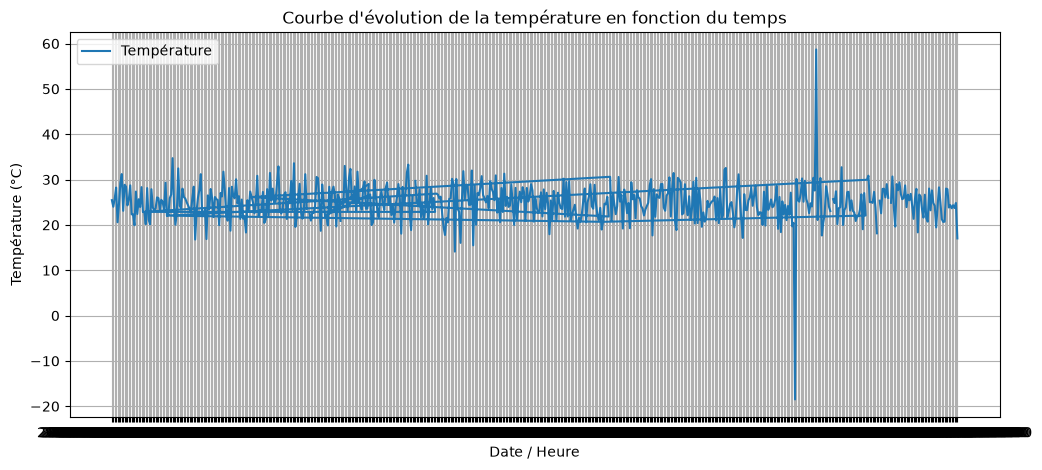

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température")
plt.title("Courbe d'évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend(loc= "upper left")
plt.grid(True)
plt.show()

### 2. Identifier visuellement les valeurs qui semblent anormales

En guise de commentaires suite à ce graphique, nous observons un pic extrême vers 59°C, très isolé, largement au-dessus du reste du nuage de points (qui oscille normalement entre ~15°C et ~35°C). On constate aussi une chute extrême vers -18°C, tout aussi isolée, largement en dessous de la plage normale. Le reste de la courbe oscille dans une bande assez régulière, grosso modo entre 15°C et 35°C, sans dérive claire vers le haut ou vers le bas sur toute la période. C'est une distribution "bruitée" (beaucoup de variations rapides d'une mesure à l'autre) mais sans tendance de fond inquiétante, pas de réchauffement ou refroidissement progressif visible à l'œil sur l'ensemble de la période.

## Partie 2:  Diagramme en barres (Bar Chart)

### 1. Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments

In [ ]:
consommation_moyenne_par_batiment = df.groupby("batiment")["consommation"].mean()
print ("La consommation moyenne par batiment est de:", consommation_moyenne_par_batiment)

La consommation moyenne par batiment est de: batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64


### 2. Comparer graphiquement la consommation moyenne des bâtiments

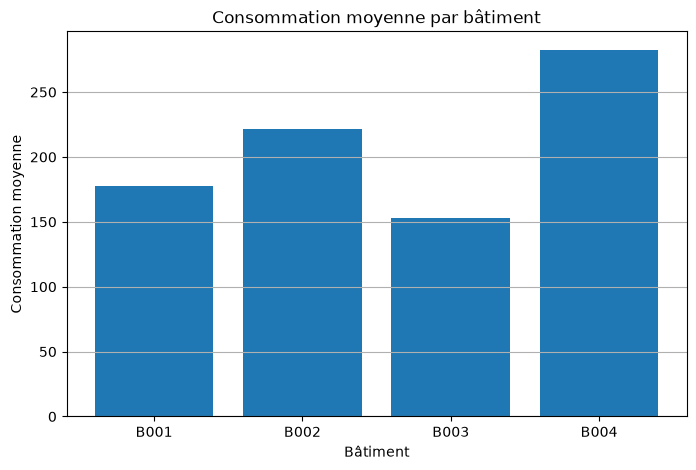

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(consommation_moyenne_par_batiment.index, consommation_moyenne_par_batiment.values)
plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")
plt.show()

### 3. Comparer la consommation moyenne des bâtiments avec un graphique horizontal

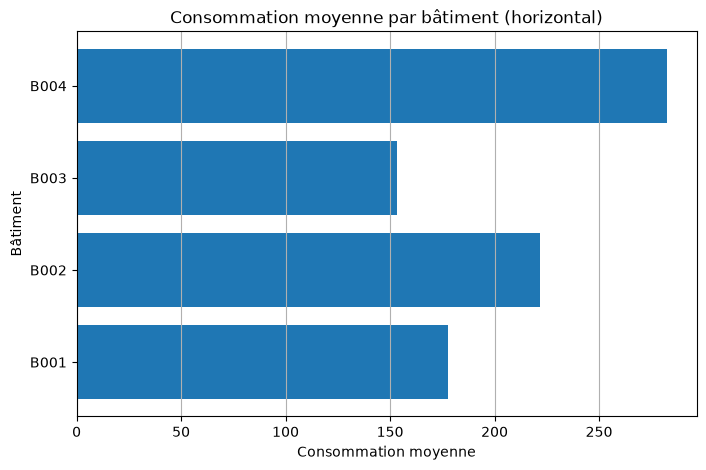

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_moyenne_par_batiment.index, consommation_moyenne_par_batiment.values)
plt.title("Consommation moyenne par bâtiment (horizontal)")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.show()

### 4. Dans quel cas un graphique horizontal peut il etre plus etre visible

Premièrement, quand les noms des catégories sont longs (des textes qui se chevaucheraient ou seraient tronqués en position verticale sous l'axe X), un graphique horizontal placent les étiquettes à gauche de chaque barre, sur une ligne complète, sans rotation ni troncature. De plus, quand il y a beaucoup de catégories à afficher, en horizontal, les barres s'empilent de haut en bas et peuvent être plus épaisses. L'œil suit naturellement une liste verticale ; on peut faire défiler si nécessaire (dans un rapport, un PDF, etc.). 
Enfin, L'œil humain compare plus facilement des longueurs horizontales alignées sur une base verticale commune que des hauteurs verticales alignées sur une base horizontale, surtout quand les étiquettes sont longues. Cela vient du fait que la lecture naturelle (occidentale) se fait de gauche à droite ; les étiquettes placées à gauche guident l'œil vers la barre.

## Partie 3: Histogramme

### 1. Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille

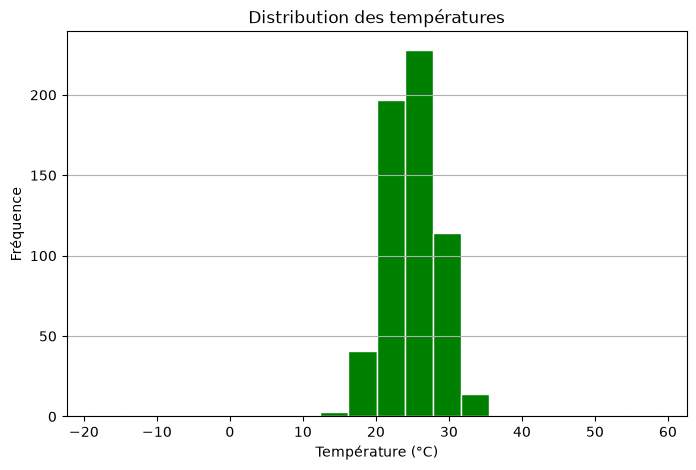

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"].dropna(), bins=20, color= "green", edgecolor="white")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.show()

**Analyse A: où se concentrent les températures**

La très grande majorité des mesures se situe entre 20°C et 30°C, avec un pic très net autour de 25-27°C (la barre la plus haute, environ 230 mesures). C'est la plage de fonctionnement "normale" des capteurs. Les barres à 17-20°C et 30-33°C existent mais sont nettement plus basses donc moins fréquentes, mais toujours dans une zone plausible.

**Analyse B: si la distribution semble symétrique**

A gauche, la barre entre 20-22°C atteint environ 195 ; à droite, à égale distance, la barre entre 30-32°C atteint seulement environ 115. La distribution n'est pas parfaitement symétrique. Elle est légèrement resserrée à droite du pic, avec une "descente" un peu plus rapide côté droit que côté gauche. On appelle ça une légère asymétrie . Ce n'est pas une cloche parfaitement équilibrée, mais l'écart reste modéré.

**Analyse C: s'il existe des valeurs très éloignées**

En effet, à gauche (vers -18/-20°C) et tout à fait à droite (vers 58-60°C) on observe deux petites barres quasiment invisibles.Ceux sont exactement les valeurs abberrants qu'on avait repérés sur la courbe précédente. Le grand espace vide entre ces barres isolées et le groupe principal (de -18°C jusqu'à 12°C, puis de 35°C jusqu'à 58°C, il n'y a rien du tout) est le signal visuel le plus clair d'une donnée exceptionnelle, pas d'une variation normale.

**Analyse D: si des valeurs aberrantes sont visibles**

D'après notre analyse précédente, nous constatons effectivement des valeurs aberrantes dans l'intervalle des -18°c puis après dans la partie des 58°c. Ces valeurs de par leur éloignement suggere un problème et se décline comme aberrantes

### 3. Afficher la distribution de la consommation en divisant la plage des données en 20 classes

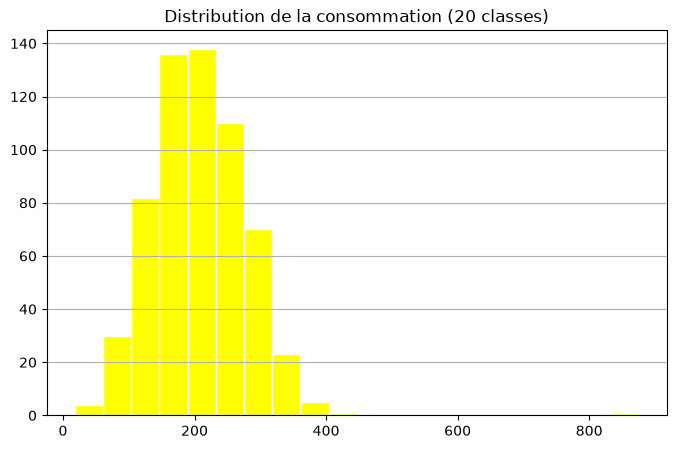

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=20, color= "yellow", edgecolor = "white")
plt.title("Distribution de la consommation (20 classes)")
plt.grid(axis="y")
plt.show()

**a. Modifier le nombre de classes à 10**

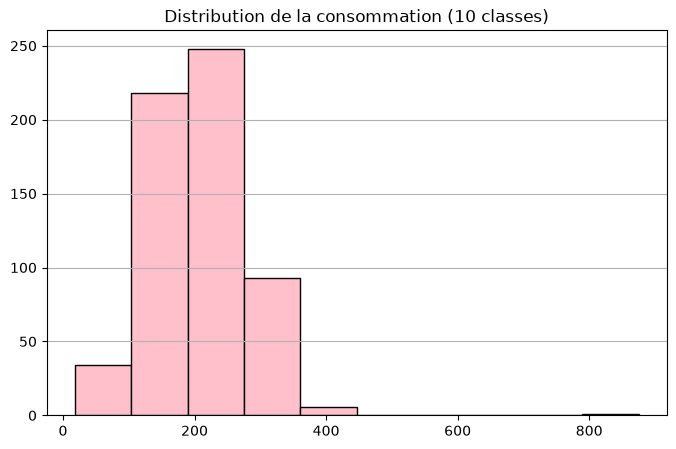

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=10, color= "pink", edgecolor= "black")
plt.title("Distribution de la consommation (10 classes)")
plt.grid(axis="y")
plt.show()

**b. Modifier le nombre de classes à 30**

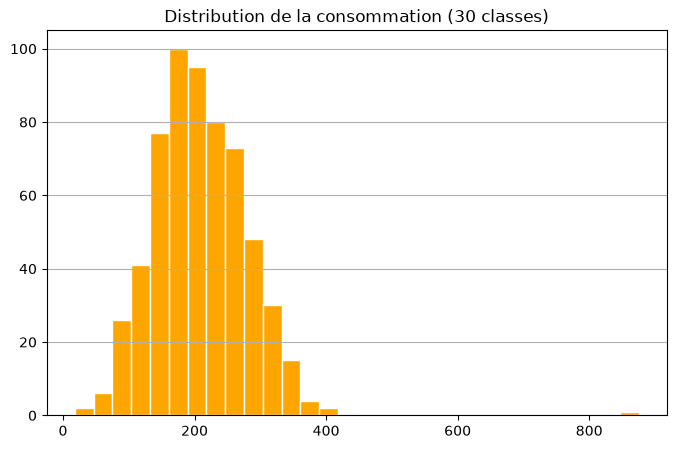

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=30, color= "orange", edgecolor= "white")
plt.title("Distribution de la consommation (30 classes)")
plt.grid(axis="y")
plt.show()

**c. Quel impact le nombre de classes a t'il sur l'interprétation**

Avec peu de classes (10), chaque barre regroupe une plage large de valeurs. Le graphique devient plus "lisse", montrant la tendance générale mais masquant les détails fins de la distribution. Avec beaucoup de classes (30), chaque barre couvre une plage étroite et on voit plus de détails et de variations, mais le graphique peut devenir "bruité" (des irrégularités qui ne reflètent que le hasard de l'échantillon, pas une vraie tendance). Il y a un compromis à trouver : trop peu de classes cache l'information, trop de classes noie l'information dans du bruit visuel.

## Partie 4: Nuage de points (Scatter Plot)

### 1. Réaliser un nuage de points entre température et consommation

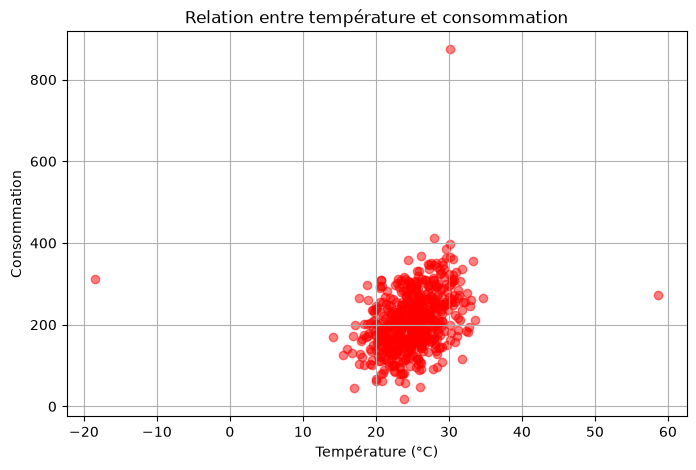

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["consommation"], color= "red", alpha= 0.5)
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.show()

### 2. Déterminer visuellement s'il semble exister une relation entre les deux

L'immense majorité des points se concentre dans une zone dense, entre 20-30°C en température et 0-400 en consommation. La forme est plutôt arrondi, sans direction diagonale claire. Ainsi, nous pouvons dire qu'il ne semble pas exister de relation linéaire nette entre température et consommation. Si la consommation augmentait vraiment avec la température (ou diminuait), on verrait le nuage s'étirer clairement en diagonale, comme une bande allongée. Ici, ce n'est pas le cas. Le nuage reste compact et centré, sans direction privilégiée. Pour une même température (par exemple 25°C), la consommation varie énormément (de moins de 100 à plus de 350), ce qui renforce l'idée qu'un autre facteur que la température explique davantage ces variations.

## Partie 5: Diagramme à moustache (Box plot)

### 1. Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant de construire le graphique et afficher uniquement les lignes horizontales de la grille

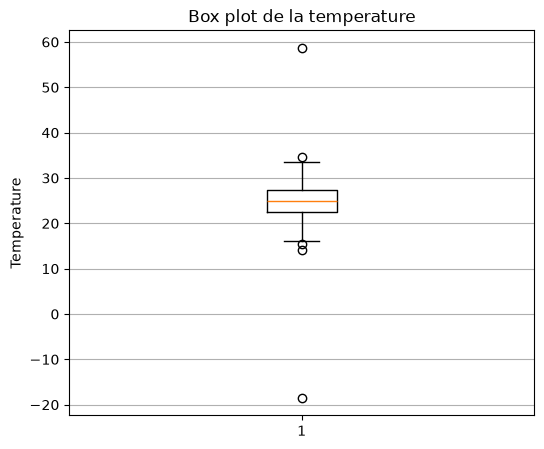

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["temperature"].dropna())
plt.title("Box plot de la temperature")
plt.ylabel("Temperature")
plt.grid(axis="y")
plt.show()

### 2. Que représentent les points situés en dehors des moustaches ?

Les points situés en dehors des moustahes représentent des valeurs extremes. Ceux sont les valeurs aberrantes (outliers) : des mesures statistiquement très éloignées du reste de la distribution plus précisément, situées au-delà de 1,5 fois l'écart interquartile (IQR) par rapport aux bords de la boîte. Matplotlib les affiche individuellement comme des points isolés plutôt que de prolonger les moustaches jusqu'à eux, justement pour les signaler comme suspects.

### 3. Créer un box plot de la consommation

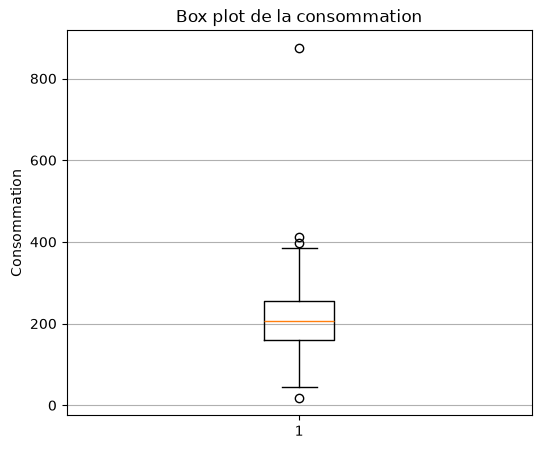

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["consommation"].dropna())
plt.title("Box plot de la consommation")
plt.ylabel("Consommation")
plt.grid(axis="y")
plt.show()

### 4. A partir des deux box plot, comparer :

**a. la position de la médiane**

Pour le graphique de la température, la médiane (trait orange) se situe autour de 25°C, à peu près au centre de la boîte. La boîte est relativement équilibrée entre le bas (~23°C) et le haut (~27°C). Sur celui de la consommation, la médiane se situe autour de 205, elle aussi assez centrée dans sa boîte (~160 à ~255).

Dans les deux cas, la médiane est plutôt bien centrée à l'intérieur de sa boîte, sans être clairement décalée vers un bord ce qui suggère une distribution relativement équilibrée pour les 50% de valeurs centrales, dans les deux variables.

**b. Taille de la boîte (IQR — écart interquartile)**

Sur le graphique de la température, la boîte est assez fine avec environ 23°C à 27°C → un écart d'à peu près 4°C et pour la consommation,la boîte nettement plus large, environ 160 à 255 → un écart d'à peu près 95.

Le constat général est  que en valeur absolue, la boîte de la consommation est beaucoup plus grande que celle de la température.

**c. Longueur des moustaches**

Température : moustaches courtes, allant d'environ 14°C à 34°C, une étendue "normale" d'environ 20°C au total.
Consommation : moustaches beaucoup plus longues en proportion, allant d'environ 40 à 390, une étendue "normale" d'environ 350 au total.

Constat : la consommation a des moustaches proportionnellement plus étirées, ce qui indique une plus grande variabilité des valeurs non-aberrantes autour de la boîte centrale.

**d. Valeurs extrêmes (points isolés au-delà des moustaches)**

Température : 2 valeurs extrêmes clairement visibles. Un point isolé très haut (~58°C) et un point isolé très bas (~-18°C). Ce sont exactement les deux anomalies déjà repérées sur l'histogramme et le nuage de points précédents.
Consommation : On note plusieurs valeurs extrêmes avec un petit groupe de points juste au-dessus de la moustache haute (autour de 400-420), un point isolé très haut (~875, celui déjà repéré sur le scatter plot), et un point bas isolé (~20).

Constat : la consommation présente davantage de valeurs extrêmes différentes (plusieurs points à des niveaux distincts), alors que la température n'en a que deux, mais toutes deux très éloignées du reste.

### 5. La consommation présente-t-elle davantage de dispersion que la température ?

Oui. Deux indices convergent vers cette conclusion :

Proportionnellement à leur propre échelle, les moustaches de la consommation couvrent une étendue beaucoup plus large autour de la médiane que celles de la température (grossièrement, la boîte à moustaches de la consommation s'étend sur presque toute la hauteur de son graphique, alors que celle de la température reste concentrée sur une plage étroite en bas de son échelle 0-60).
La consommation affiche plus de valeurs extrêmes distinctes (plusieurs points à différents niveaux), suggérant des événements ponctuels plus fréquents ou plus variés que pour la température, qui n'a que deux anomalies isolées.

En résumé : la température se comporte comme une variable assez stable et prévisible autour de sa médiane (peu de dispersion, hormis 2 erreurs de mesure ponctuelles), tandis que la consommation varie beaucoup plus largement d'une mesure à l'autre, cohérent avec ce qu'on avait observé sur le nuage de points, où la consommation variait fortement même à température constante, suggérant l'influence d'autres facteurs (usage, horaires, équipements) plutôt que la seule température.

## Partie 6: Diagramme circulaire (Pie Chart)

### 1. Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR)

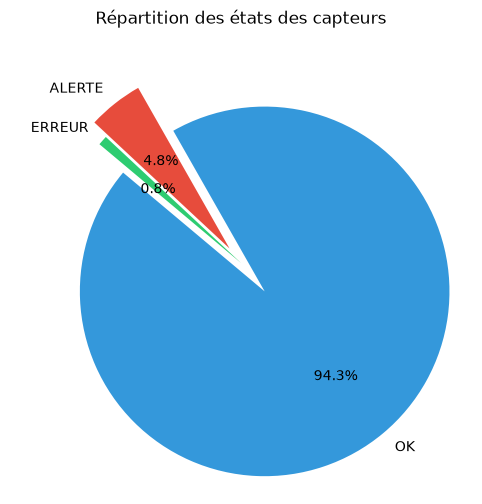

In [ ]:
repartition_etat = df["etat"].value_counts()

plt.figure(figsize=(6, 6))
couleurs = ['#3498db', '#e74c3c', '#2ecc71']
explode = (0.2, 0.1, 0) # Détache le secteur 'Matériel'
plt.pie(repartition_etat.values, explode=explode, labels=repartition_etat.index, colors=couleurs, autopct="%1.1f%%", startangle=140)
plt.title("Répartition des états des capteurs")
plt.show()

### 2. interpréter la proportion de capteurs OK ; proportion ALERTE ; proportion ERREUR

Le diagramme circulaire se présente comme rassurant vu la dominance du pourcentage de OK (94,3%). Cela suggère peu d'incidents avec toutefois quelques alertes (4,8%) et erreurs (0,8%) qui méritent un point d'attention surtout par rapport à la maintenance des capteurs.

## Partie 7: Plusieurs courbes sur un même graphique

### Construire sur un même graphique « Évolution de la température par bâtiment" » des quatre bâtiments.

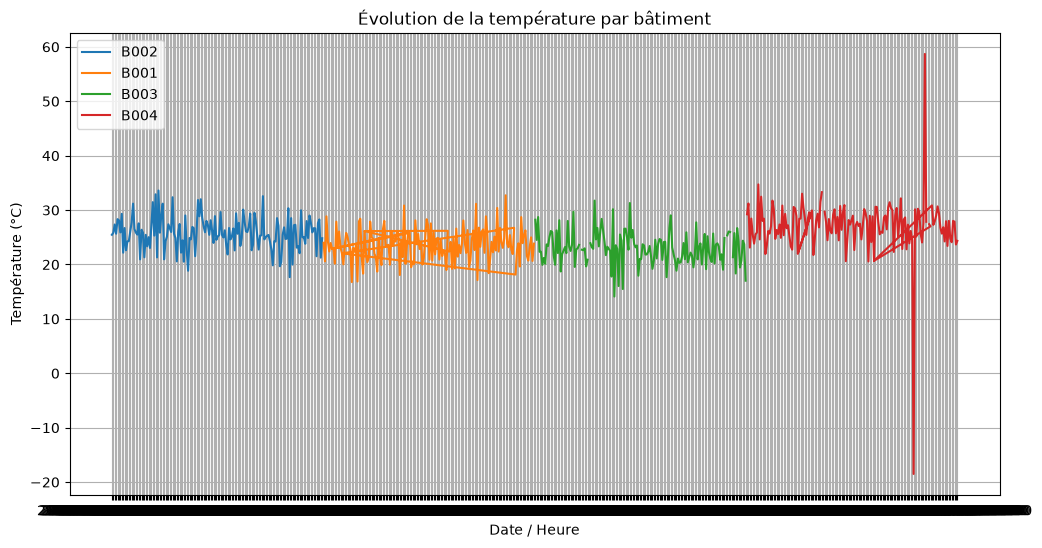

In [ ]:
plt.figure(figsize=(12, 6))

for batiment in df["batiment"].unique():
    df_batiment = df[df["batiment"] == batiment]
    plt.plot(df_batiment["date_heure"], df_batiment["temperature"], label=batiment)

plt.title("Évolution de la température par bâtiment")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.show()

## Partie 8: Sauvegarde des graphiques

### 1. Sauvegarder le graphique sur l'évolution de la température en fonction du temps dans exports/ temperature.png

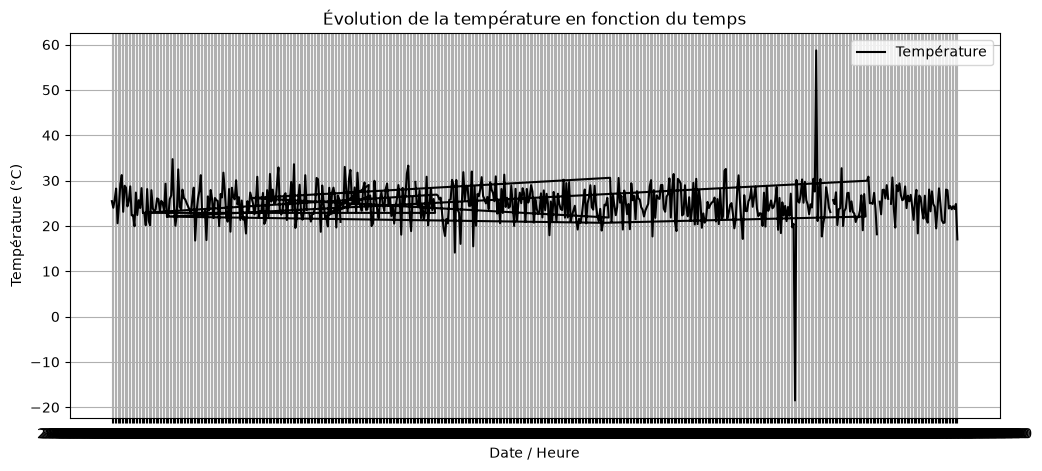

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température", color= "black")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)


plt.savefig("../exports/temperature.png")
plt.show()

### 2. Sauvegarder le graphique sur l'évolution de la température en fonction du temps dans exports/ temperature.pdf

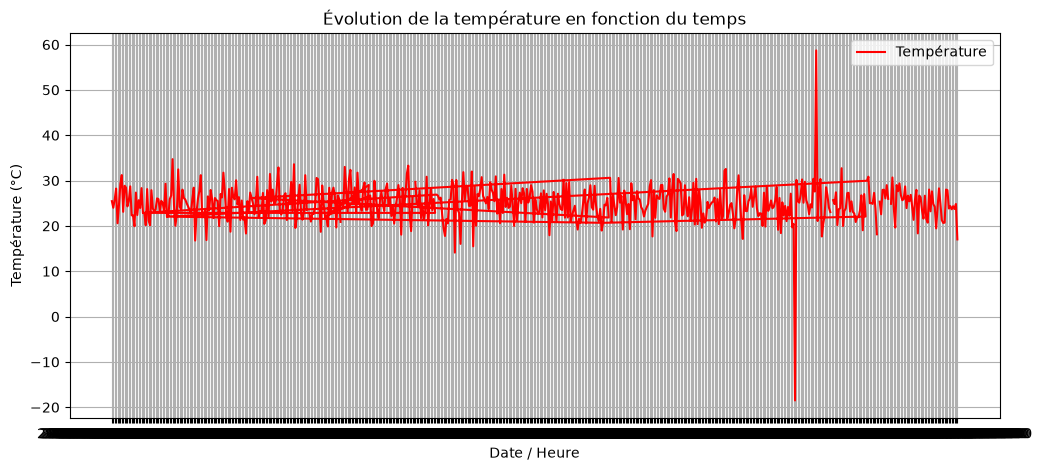

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température", color= "red")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)


plt.savefig("../exports/temperature.pdf")
plt.show()

## Partie 9: Bonus

Faisons un subplot (grille de plusieurs graphiques côte à côte, avec `plt.subplots()`) regroupant température, humidité et consommation sur une seule image de synthèse.

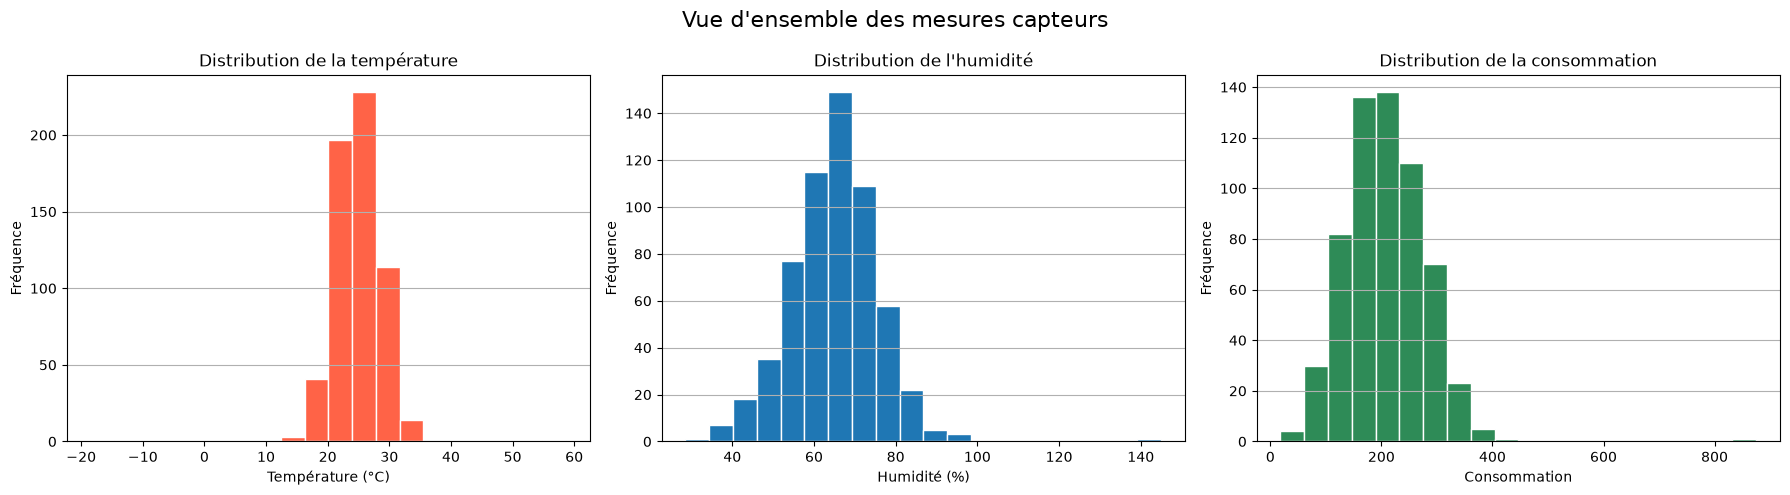

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# ----- Graphique 1 : Température -----
axes[0].hist(df["temperature"].dropna(), bins=20, color="tomato", edgecolor= "white")
axes[0].set_title("Distribution de la température")
axes[0].set_xlabel("Température (°C)")
axes[0].set_ylabel("Fréquence")
axes[0].grid(axis="y")

# ----- Graphique 2 : Humidité -----
axes[1].hist(df["humidite"].dropna(), bins=20, edgecolor= "white")
axes[1].set_title("Distribution de l'humidité")
axes[1].set_xlabel("Humidité (%)")
axes[1].set_ylabel("Fréquence")
axes[1].grid(axis="y")

# ----- Graphique 3 : Consommation -----
axes[2].hist(df["consommation"].dropna(), bins=20, color="seagreen", edgecolor= "white")
axes[2].set_title("Distribution de la consommation")
axes[2].set_xlabel("Consommation")
axes[2].set_ylabel("Fréquence")
axes[2].grid(axis="y")

# Titre global au-dessus des 3 graphiques
fig.suptitle("Vue d'ensemble des mesures capteurs", fontsize=16)

plt.tight_layout()
plt.savefig("../exports/synthese_capteurs.png")
plt.show()

L'analyse des trois distributions révèle des capteurs globalement bien calibrés, avec des mesures qui se concentrent autour de valeurs cohérentes et peu de valeurs aberrantes visibles. La température présente une distribution unimodale et resserrée, centrée entre 20 et 30°C, avec un pic net autour de 25-28°C (environ 230 mesures) : cela correspond à une plage de confort thermique standard, sans quasiment aucune valeur en dehors de l'intervalle 10-35°C, ce qui suggère un environnement contrôlé plutôt qu'un relevé extérieur brut. L'humidité, elle, est légèrement plus étalée, avec un pic principal autour de 65% (environ 150 mesures) et une distribution qui s'étend de 30% à 100%, plus quelques valeurs isolées et anormales au-delà de 140% — physiquement impossibles pour un pourcentage, ce qui pointe vers des erreurs de capteur ou des valeurs à nettoyer avant toute analyse plus poussée. Enfin, la consommation suit une distribution proche d'une loi normale, centrée entre 150 et 250 (pic vers 200, ~135-140 mesures), avec une queue légère vers les valeurs élevées (jusqu'à ~400) et un point isolé très éloigné près de 800-900, probablement un outlier ou un pic de consommation ponctuel à vérifier.

En synthèse : les trois variables montrent des distributions globalement gaussiennes et exploitables statistiquement, mais la présence de valeurs aberrantes (humidité >140%, consommation >800) indique qu'un nettoyage des données (filtrage ou suppression des outliers) serait une étape pertinente avant toute modélisation ou calcul de statistiques descriptives (moyenne, écart-type), car ces valeurs extrêmes pourraient fausser les résultats.